In [1]:
%env CUDA_VISIBLE_DEVICES=0

env: CUDA_VISIBLE_DEVICES=0


In [2]:
from arcgis.learn import MaskRCNN, prepare_data

In [8]:
data_path = r'/mnt/Raster/Data/Tests_Data/maskrcnn/WoolseyFire_MaskRCNN'

In [4]:
# Create Databunch
data = prepare_data(data_path, batch_size=4)
data

Please check your dataset. 1 images dont have the corresponding label files.


ImageDataBunch;

Train: LabelList (1251 items)
x: ArcGISInstanceSegmentationItemList
Image (3, 224, 224),Image (3, 224, 224),Image (3, 224, 224),Image (3, 224, 224),Image (3, 224, 224)
y: ArcGISSegmentationLabelList
ArcGISImageSegment (1, 224, 224),ArcGISImageSegment (1, 224, 224),ArcGISImageSegment (1, 224, 224),ArcGISImageSegment (1, 224, 224),ArcGISImageSegment (1, 224, 224)
Path: \\ndhfs1\Raster\Data\Tests_Data\maskrcnn\WoolseyFire_MaskRCNN\images;

Valid: LabelList (139 items)
x: ArcGISInstanceSegmentationItemList
Image (3, 224, 224),Image (3, 224, 224),Image (3, 224, 224),Image (3, 224, 224),Image (3, 224, 224)
y: ArcGISSegmentationLabelList
ArcGISImageSegment (1, 224, 224),ArcGISImageSegment (1, 224, 224),ArcGISImageSegment (1, 224, 224),ArcGISImageSegment (1, 224, 224),ArcGISImageSegment (1, 224, 224)
Path: \\ndhfs1\Raster\Data\Tests_Data\maskrcnn\WoolseyFire_MaskRCNN\images;

Test: None

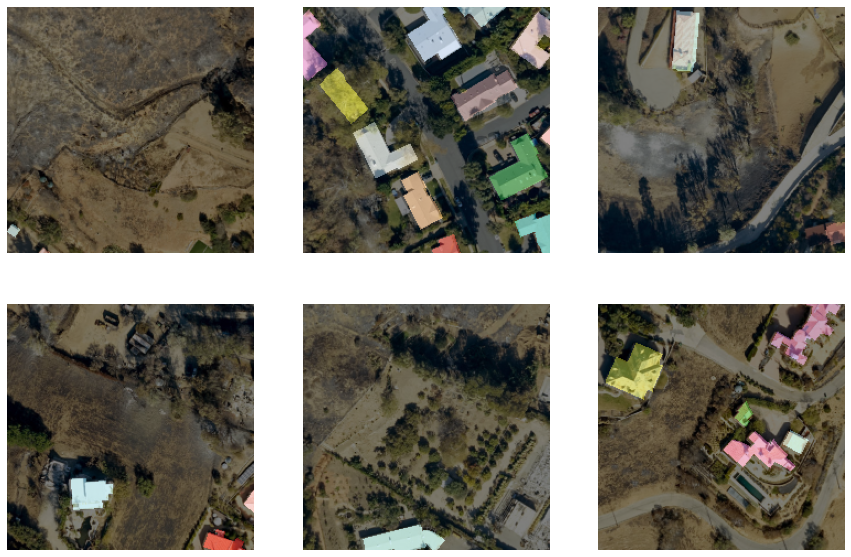

In [5]:
data.show_batch()

In [6]:
model = MaskRCNN(data)

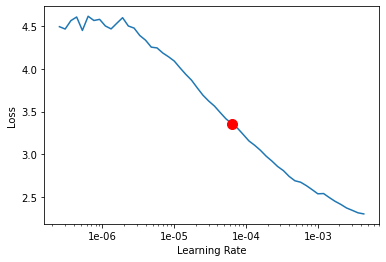

6.309573444801929e-05

In [7]:
model.lr_find()

In [8]:
model.fit(10)

epoch,train_loss,valid_loss,time
0,1.019194,0.985053,04:03
1,0.724935,0.770615,03:56
2,0.592944,0.709390,03:53
3,0.457128,0.656578,04:00
4,0.387247,0.705955,04:10
5,0.345647,0.643331,03:58
6,0.300260,0.591859,03:55
7,0.259161,0.607280,03:58
8,0.225653,0.649995,03:57
9,0.222559,0.682534,04:01


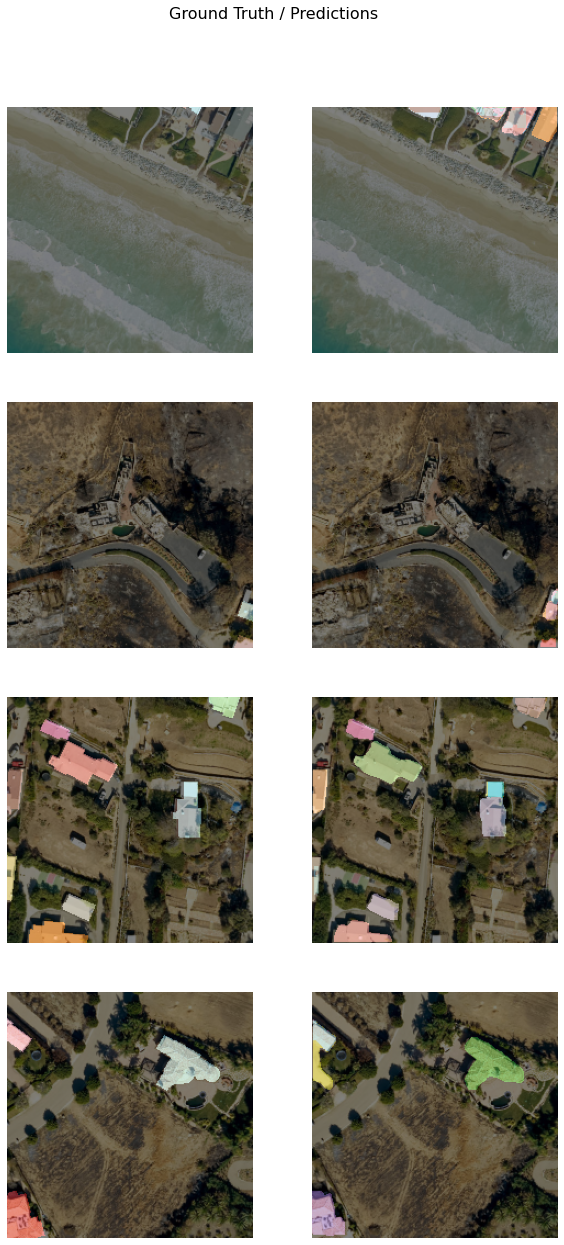

In [9]:
model.show_results()

In [11]:
model.save(r'/home/administrator/Raster/notebook_test_model')

WindowsPath('//NDHFS1/Raster/Data/testdata/extracted_data/maskrcnn_data/small-data/data/models/maskrcnn-model')

In [11]:
score = model.average_precision_score()

In [12]:
score

{'Undamaged': 0.8209670817171728}

In [13]:
score.get('Undamaged')

0.8209670817171728

In [14]:
assert score.get('Undamaged') >= 0.8